In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_groq import ChatGroq
from langgraph.graph.message import add_messages
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3
import os
from dotenv import load_dotenv

load_dotenv(override=True)
GROQ_API_KEY = os.getenv('GROQ_API_KEY')
print('Key loaded:', bool(GROQ_API_KEY))


Key loaded: True


In [2]:
# define state
from langgraph.graph.message import add_messages
class ChatState(TypedDict):
    
    """ add_message it is reducer (when we define any state then state has a charector which is
     it delete the previous messg and only hold new message but we want to keep every message so
     for that we use reduceer)"""
    messages: Annotated[list[BaseMessage], add_messages]
    

In [ ]:
# Initialize Groq LLM - using available model
llm = ChatGroq(
    model="qwen/qwen3.8-27b",
    api_key=GROQ_API_KEY
)



In [ ]:
def chat_node(state: ChatState):

    # take user query from state
    messages = state['messages']

    # send to llm
    responce = llm.invoke(messages)

    # responce store in state
    return {'messages': [responce]}

In [4]:
# define graph
graph = StateGraph(ChatState)

# add node
graph.add_node('chat_node', chat_node)

# add edges
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

# SQLite checkpointer - conversation history .db file mein save hogi
conn = sqlite3.connect('chatbot_memory.db', check_same_thread=False)
memory = SqliteSaver(conn)

# compile graph WITH checkpointer
chatbot = graph.compile(checkpointer=memory)
print('Chatbot compiled with SQLite memory!')


Chatbot compiled with SQLite memory!


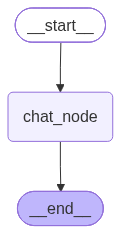

In [5]:
chatbot

In [6]:
# Test the chatbot
# thread_id REQUIRED jab bhi checkpointer use ho
config = {'configurable': {'thread_id': 'session_1'}}

result = chatbot.invoke(
    {'messages': [HumanMessage(content='Hello! What can you do?')]},
    config=config
)
print(result['messages'][-1].content)


Hello, Sarvesh! As mentioned earlier, I am a versatile AI assistant designed to help you with a wide variety of tasks. Here’s a quick overview of what I can do:

### 📝 **Writing & Editing**
*   Draft emails, reports, articles, or creative stories.
*   Edit and proofread text for grammar, clarity, and tone.
*   Summarize long documents or articles into concise key points.

### 💻 **Coding & Technical Support**
*   Write, explain, and debug code in languages like Python, JavaScript, C++, and more.
*   Help with algorithm design, data structures, and system architecture.
*   Assist with SQL queries, regex patterns, and API integrations.

### 🧠 **Analysis & Problem Solving**
*   Break down complex problems into logical steps.
*   Perform data analysis, interpret statistics, or explain scientific concepts.
*   Help with brainstorming, decision-making, and strategic planning.

### 🌍 **Language & Translation**
*   Translate text between many languages.
*   Explain grammar rules or help you pra

In [7]:
# thread_id se session track hota hai
# Same thread_id = bot yaad rakhega!
# Alag thread_id = fresh conversation
config = {'configurable': {'thread_id': 'session_1'}}

print('Thread ID: session_1 - bot is same conversation yaad rakhega\n')

while True:
    user_message = input('You: ')
    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        print('Goodbye! Conversation SQLite DB mein save hai.')
        break
    responce = chatbot.invoke(
        {'messages': [HumanMessage(content=user_message)]},
        config=config  # yahi thread_id memory ke liye key hai
    )
    print('AI:', responce['messages'][-1].content)
    print()


Thread ID: session_1 - bot is same conversation yaad rakhega

AI: Hii Sarvesh! 👋 How's it going? Is there anything specific you'd like to work on or chat about today?

Goodbye! Conversation SQLite DB mein save hai.


In [ ]:
# to check node wise snapsot of your memory

chatbot.get_state(config)


StateSnapshot(values={'messages': [HumanMessage(content='Hello! What can you do?', additional_kwargs={}, response_metadata={}, id='cadb7ca0-6969-4ae5-8342-59bd14254248'), AIMessage(content='Hello! I am a versatile AI assistant designed to help you with a wide variety of tasks. Here’s a quick overview of what I can do:\n\n### 📝 **Writing & Editing**\n*   Draft emails, reports, articles, or creative stories.\n*   Edit and proofread text for grammar, clarity, and tone.\n*   Summarize long documents or articles into concise key points.\n\n### 💻 **Coding & Technical Support**\n*   Write, explain, and debug code in languages like Python, JavaScript, C++, and more.\n*   Help with algorithm design, data structures, and system architecture.\n*   Assist with SQL queries, regex patterns, and API integrations.\n\n### 🧠 **Analysis & Problem Solving**\n*   Break down complex problems into logical steps.\n*   Perform data analysis, interpret statistics, or explain scientific concepts.\n*   Help with 

In [ ]:
# As we know persistence save each node output so we can se it visually what each node shoud store 
list(chatbot.get_state_history(config))


[StateSnapshot(values={'messages': [HumanMessage(content='Hello! What can you do?', additional_kwargs={}, response_metadata={}, id='cadb7ca0-6969-4ae5-8342-59bd14254248'), AIMessage(content='Hello! I am a versatile AI assistant designed to help you with a wide variety of tasks. Here’s a quick overview of what I can do:\n\n### 📝 **Writing & Editing**\n*   Draft emails, reports, articles, or creative stories.\n*   Edit and proofread text for grammar, clarity, and tone.\n*   Summarize long documents or articles into concise key points.\n\n### 💻 **Coding & Technical Support**\n*   Write, explain, and debug code in languages like Python, JavaScript, C++, and more.\n*   Help with algorithm design, data structures, and system architecture.\n*   Assist with SQL queries, regex patterns, and API integrations.\n\n### 🧠 **Analysis & Problem Solving**\n*   Break down complex problems into logical steps.\n*   Perform data analysis, interpret statistics, or explain scientific concepts.\n*   Help with

In [16]:
# thread_id se session track hota hai
# Same thread_id = bot yaad rakhega!
# Alag thread_id = fresh conversation
# Just use a new name → starts with 0 snapshots
config_1 = {'configurable': {'thread_id': 'session_fresh_1'}}

print('Thread ID: session_fresh_1 - bot is same conversation yaad rakhega\n')

while True:
    user_message = input('You: ')
    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        print('Goodbye! Conversation SQLite DB mein save hai.')
        break
    responce = chatbot.invoke(
        {'messages': [HumanMessage(content=user_message)]},
        config=config_1  # yahi thread_id memory ke liye key hai
    )
    print('AI:', responce['messages'][-1].content)
    print()

Thread ID: session_fresh_1 - bot is same conversation yaad rakhega

AI: Hi there! How can I help you today?

Goodbye! Conversation SQLite DB mein save hai.


In [17]:
list(chatbot.get_state_history(config_1))


[StateSnapshot(values={'messages': [HumanMessage(content='hii', additional_kwargs={}, response_metadata={}, id='2f028a65-74f0-40ff-9352-1f0eafc1d3df'), AIMessage(content='Hi there! How can I help you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 14, 'total_tokens': 25, 'completion_time': 0.021086744, 'completion_tokens_details': None, 'prompt_time': 0.000694602, 'prompt_tokens_details': None, 'queue_time': 0.048609488, 'total_time': 0.021781346}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_21e59ac2de', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a1034e-b206-7933-af3e-b4eb33c5512a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 11, 'total_tokens': 25})]}, next=(), config={'configurable': {'thread_id': 'session_fresh_1', 'checkpoint_ns': '', 'checkpoint_id': '1f1bf634-5a54-6423-8001-1b1e9673861f'}

### Time Travel 

In [18]:
chatbot.get_state({'configurable':{'thread_id': "session_fresh_1",'checkpoint_id': '1f1bf634-58b0-66f7-8000-e64a755d5d7d'}})

StateSnapshot(values={'messages': [HumanMessage(content='hii', additional_kwargs={}, response_metadata={}, id='2f028a65-74f0-40ff-9352-1f0eafc1d3df')]}, next=('chat_node',), config={'configurable': {'thread_id': 'session_fresh_1', 'checkpoint_id': '1f1bf634-58b0-66f7-8000-e64a755d5d7d'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-10-03T19:47:31.460274+00:00', parent_config={'configurable': {'thread_id': 'session_fresh_1', 'checkpoint_ns': '', 'checkpoint_id': '1f1bf634-58ab-68c6-bfff-4db46c8d0d86'}}, tasks=(PregelTask(id='adf671d6-93b1-de4b-d0bf-0d2794b0c09c', name='chat_node', path=('__pregel_pull', 'chat_node'), error=None, interrupts=(), state=None, result={'messages': [AIMessage(content='Hi there! How can I help you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 14, 'total_tokens': 25, 'completion_time': 0.021086744, 'completion_tokens_details': None, 'prompt_time': 0.000694602, 'prompt_token

In [19]:
chatbot.invoke(None, {'configurable':{'thread_id': "session_fresh_1",'checkpoint_id': '1f1bf634-58b0-66f7-8000-e64a755d5d7d'}})

{'messages': [HumanMessage(content='hii', additional_kwargs={}, response_metadata={}, id='2f028a65-74f0-40ff-9352-1f0eafc1d3df'),
  AIMessage(content='Hi there! How can I help you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 14, 'total_tokens': 25, 'completion_time': 0.021136916, 'completion_tokens_details': None, 'prompt_time': 0.000743256, 'prompt_tokens_details': None, 'queue_time': 0.048403524, 'total_time': 0.021880172}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_a1293f40b5', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a1036b-857f-79c3-9365-56a78ae9f980-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 11, 'total_tokens': 25})]}

In [ ]:
list(chatbot.get_state_history(config_1))


[StateSnapshot(values={'messages': [HumanMessage(content='hii', additional_kwargs={}, response_metadata={}, id='2f028a65-74f0-40ff-9352-1f0eafc1d3df'), AIMessage(content='Hi there! How can I help you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 14, 'total_tokens': 25, 'completion_time': 0.021136916, 'completion_tokens_details': None, 'prompt_time': 0.000743256, 'prompt_tokens_details': None, 'queue_time': 0.048403524, 'total_time': 0.021880172}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_a1293f40b5', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a1036b-857f-79c3-9365-56a78ae9f980-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 11, 'total_tokens': 25})]}, next=(), config={'configurable': {'thread_id': 'session_fresh_1', 'checkpoint_ns': '', 'checkpoint_id': '1f1bf67a-bad5-6c20-8002-4cd72a339ec6'}

In [23]:
from langchain_core.messages import HumanMessage

chatbot.update_state(
    {
        'configurable': {
            'thread_id': 'session_fresh_1',
            'checkpoint_ns': '',            # ✅ Add this! Empty string for root graph
            'checkpoint_id': '1f1bf634-58b0-66f7-8000-e64a755d5d7d'
        }
    },
    {
        'messages': [HumanMessage(content='what is ai')]
    }
)


{'configurable': {'thread_id': 'session_fresh_1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1bf686-19f2-6db6-8001-d47308dadbb6'}}

In [24]:
list(chatbot.get_state_history(config_1))


[StateSnapshot(values={'messages': [HumanMessage(content='hii', additional_kwargs={}, response_metadata={}, id='2f028a65-74f0-40ff-9352-1f0eafc1d3df'), HumanMessage(content='what is ai', additional_kwargs={}, response_metadata={}, id='7af23240-196e-4446-9ff3-350acc3c7b60')]}, next=('chat_node',), config={'configurable': {'thread_id': 'session_fresh_1', 'checkpoint_ns': '', 'checkpoint_id': '1f1bf686-19f2-6db6-8001-d47308dadbb6'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-10-03T20:24:06.052191+00:00', parent_config={'configurable': {'thread_id': 'session_fresh_1', 'checkpoint_ns': '', 'checkpoint_id': '1f1bf634-58b0-66f7-8000-e64a755d5d7d'}}, tasks=(PregelTask(id='1037b190-e8b9-9641-970e-0417bb3ad2a8', name='chat_node', path=('__pregel_pull', 'chat_node'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'messages': [HumanMessage(content='hii', additional_kwargs={}, response_metadata={}, id='2f028a65-74f0-40ff